In [132]:
# 导入库
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib as mpl
import matplotlib.patches as mpatches
import scipy.io

In [164]:
# 设置随机种子
np.random.seed(23)

In [183]:
# 定义高斯分布参
mean1 = [0, 0]
mean2 = [5, 0]
mean3 = [3, 3]

cov = [[0.9, 0.4],
      [0.4, 0.3]]

In [184]:
# 每组50point
data1 = np.random.multivariate_normal(mean1, cov, 50)
data2 = np.random.multivariate_normal(mean2, cov, 50)
data3 = np.random.multivariate_normal(mean3, cov, 50)

In [185]:
# 合并数据，150个点
data = np.vstack((data1, data2, data3))
X = data

# 保存到data.txt文件 每行一个二维点
np.savetxt("data/data.txt", X, fmt="%.6f")

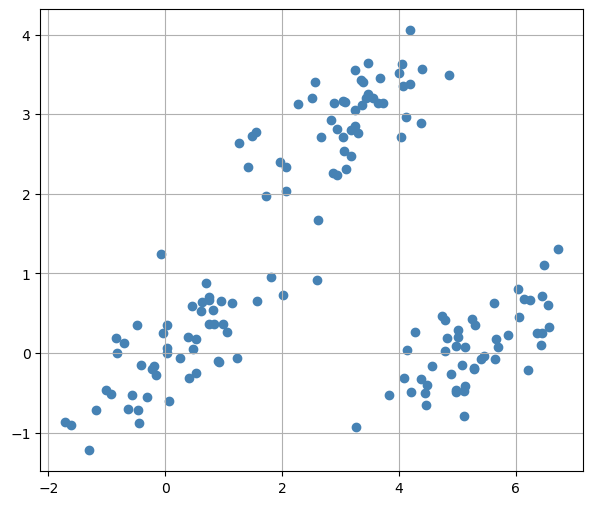

In [186]:
# 读取文件 绘制散点图
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c="steelblue")
plt.grid(True)
plt.show()

In [187]:
# 随机初始化质心
def kMeansInitCentroids(X, k):
    #从X的数据中随机取k个作为质心
    index = np.random.randint(0,len(X)-1,k)
    return X[index]

In [188]:
# 计算数据点到质心的距离，并判断该数据点属于哪个质心
def findClosestCentroids(X, centroids):
    #idx中数据表明对应X的数据是属于哪一个质心的
    idx = np.zeros(len(X)).reshape( X.shape[0],-1)
    for i in range(len(X)):
        minDistance = float('inf');#初始无限大
        index = 0
        for k in range(len(centroids)):
            #距离计算，使用欧几里得距离
            distance = np.sum(np.power(X[i]-centroids[k],2))
            if(distance<minDistance):
                minDistance = distance
                index = k
        idx[i]=index
    return idx

In [189]:
# 重新计算质心
def computeCentroids(X, idx):
    k = set(np.ravel(idx).tolist()) #找到所有聚类中心索引
    k = list(k)
    centroids = np.ndarray((len(k),X.shape[1]))
    for i in range(len(k)):
        #选择数据X中类别为k[i]的数据
        data = X[np.where(idx==k[i])[0]]
        #重新计算聚类中心
        centroids[i] = np.sum(data,axis=0)/len(data)
    return centroids

In [190]:
# 合成 k-means 算法（限制迭代次数版）
def k_means(X, k, max_iters):
    initial_centroids = kMeansInitCentroids(X,k)
    #迭代
    for i in range(max_iters):
        if i==0:
            centroids = initial_centroids
        #计算样本到质心的距离，并返回每个样本所属的质心
        idx = findClosestCentroids(X, centroids)
        #重新计算聚类中心
        centroids = computeCentroids(X, idx)
    return idx,centroids

idx,centroids = k_means(X, 3, 8)
# print(idx)
print(centroids)

[[0.14944859 0.04377095]
 [5.27941531 0.0616308 ]
 [3.10657679 2.91228945]]


In [191]:
# # 合成 k-means 算法（不限制迭代次数版）
# def k_means(X, k):
#     initial_centroids = kMeansInitCentroids(X,k)
#     centroids = initial_centroids
#     #计算样本到质心的距离，并返回每个样本所属的质心
#     idx = findClosestCentroids(X, centroids)
#     #重新计算聚类中心
#     centroids = computeCentroids(X, idx)
#     return idx,centroids

# idx,centroids = k_means(X, 3)
# # print(idx)
# print(centroids)

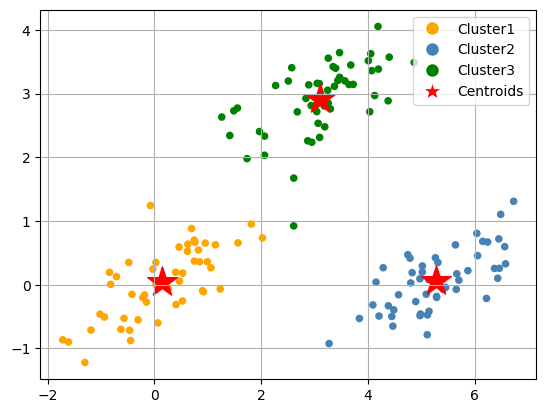

In [192]:
# 绘制聚类后散点图
from matplotlib.lines import Line2D
cm_dark = mpl.colors.ListedColormap(['orange', 'steelblue', 'green'])

plt.scatter(X[:, 0], X[:, 1], c=np.ravel(idx), cmap=cm_dark, s=20)
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker='*', s=500)

# 构造图例：前三个 Cluster 用圆点，Centroids 用五角星
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Cluster1',
           markerfacecolor='orange', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster2',
           markerfacecolor='steelblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster3',
           markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='*', color='w', label='Centroids',
           markerfacecolor='red', markersize=15)
]

plt.legend(handles=legend_elements, loc='upper right')
plt.grid(True)
plt.show()